# De la DTFT a la DFT

## Paso 1 — Definición de la DTFT
La **Transformada de Fourier en Tiempo Discreto (DTFT)** de una señal discreta cualquiera \(x[n]\) está definida como:

$$
X(e^{j\omega}) = \sum_{n=-\infty}^{\infty} x[n] \, e^{-j\omega n}, 
\quad \omega \in \mathbb{R}.
$$

Aquí la variable de frecuencia \(\omega\) es **continua**, lo que hace que la DTFT sea un espectro continuo y periódico.


### Paso 2 — Señal de duración finita
Si la señal es no nula solo en el intervalo \(0 \leq n \leq N-1\), entonces:

$$
x[n] = 0 \quad \text{para } n < 0 \;\; \text{o} \;\; n \geq N,
$$

y la suma infinita se reduce a un rango finito:

$$
X(e^{j\omega}) = \sum_{n=0}^{N-1} x[n] \, e^{-j\omega n}.
$$


### Paso 3 — Muestreo en frecuencias discretas
En lugar de considerar todos los valores continuos de \(\omega\), tomamos solo \(N\) frecuencias igualmente espaciadas:

$$
\omega_k = \frac{2\pi}{N}k, 
\quad k = 0,1,\dots,N-1.
$$



### Paso 4 — Evaluación de la DTFT en esas frecuencias
Sustituyendo \(\omega = \omega_k\) en la expresión de la DTFT:

$$
X(e^{j\omega_k}) = \sum_{n=0}^{N-1} x[n] \, e^{-j\omega_k n}.
$$

Reemplazando el valor de \(\omega_k\):

$$
X(e^{j\omega_k}) = \sum_{n=0}^{N-1} x[n] \, e^{-j\frac{2\pi}{N}kn}.
$$


### Paso 5 — Definición de la DFT
A estos valores muestreados se los denomina **coeficientes de la DFT**:

$$
X[k] \;\stackrel{\text{def}}{=}\; X(e^{j\omega_k})
= \sum_{n=0}^{N-1} x[n]\; e^{-j\frac{2\pi}{N}kn}, 
\quad k=0,1,\dots,N-1.
$$

---

## Conclusión
- La **DTFT** es una representación **continua y periódica** en frecuencia.  
- La **DFT** se obtiene al **muestrear la DTFT en \(N\) frecuencias equiespaciadas**:

$$
\omega_k = \frac{2\pi}{N}k.
$$

En resumen:

$$
\text{DFT} \;=\; \text{DTFT evaluada en } \omega_k.
$$



## Transformada Discreta de Fourier (DFT)

La **DFT** es una herramienta matemática que permite convertir una señal discreta en el tiempo en su representación en frecuencia.

En el caso de **OFDM**, se utiliza para **separar las distintas portadoras** y **recuperar los símbolos transmitidos**.

$$
X_k = \sum_{n=0}^{N-1} x_n \cdot e^{-j \frac{2\pi}{N}kn}, \quad k = 0, 1, \ldots, N-1
$$

- **\(x_n\)**: son las muestras de la señal en el tiempo.  
- **\(X_k\)**: componente en frecuencia correspondiente a la frecuencia discreta \(k\).  
- **\(N\)**: número total de portadoras.  

### Funciones base y ortogonalidad

- Un conjunto de funciones es una **base** de un espacio de funciones si:
  1. Cumple con la **independencia lineal**.
  2. Cualquier función del espacio puede escribirse como **combinación lineal** de las funciones base.

- Las exponenciales son \(N\) **sinusoides complejas ortogonales**.

- Multiplicar \(x_n\) por la exponencial es **proyectar la señal** sobre la sinusoide compleja de frecuencia \(k\).

- El resultado \(X_k\) indica **cuánto contenido** (en amplitud y fase) tiene la señal en esa frecuencia.

- En **OFDM**, ese contenido representa el **símbolo transmitido** en la portadora \(k\).

- En OFDM, se usa la **DFT** para pasar de la señal recibida en el tiempo a los símbolos en frecuencia.

- La **FFT** es un algoritmo eficiente para calcular la DFT. Matemáticamente, ambas dan el mismo resultado.

- La FFT no cambia la fórmula, solo la implementa usando una **técnica recursiva** que reduce el número de operaciones.

---

### Transformada Inversa Discreta de Fourier (IDFT)

- La **IDFT** es la operación matemática que convierte una señal en el **dominio de la frecuencia** a su representación en el **dominio del tiempo**.

- En OFDM, se utiliza en el **transmisor** para construir la **señal compuesta** que luego será enviada por el canal.

$$
x_n = \frac{1}{N} \sum_{k=0}^{N-1} X_k \cdot e^{j \frac{2\pi}{N}kn}, \quad n = 0, 1, \ldots, N-1
$$

### Parámetros en la IDFT

- \( X_k \): Componentes en frecuencia, símbolos modulados en cada portadora.  
- \( x_n \): Muestras de la señal en el tiempo (señal OFDM).  
- \( N \): Número de portadoras.  

---

### Funciones base en la IDFT

- Las exponenciales son las **mismas funciones base** que en la DFT pero con el **signo del exponente cambiado**.
- Esto significa que, en lugar de **proyectar** sobre las bases (como en la DFT), **sumamos** para construir la señal.
- Cada \( X_k \) se multiplica por su **función base correspondiente** y todas se suman para formar \( x_n \).
- La **IDFT** toma \( N \) sinusoides ortogonales y las suma para obtener una señal compuesta.
- Cada \( X_k \) define la **amplitud y fase** de la sinusoide de frecuencia \( k \).
- El resultado es una señal que contiene **todas las portadoras transmitidas simultáneamente**.

---

### Algoritmo IFFT

- La **IFFT** es un algoritmo eficiente para calcular la IDFT.
- Matemáticamente, la IDFT y la IFFT dan **exactamente el mismo resultado**.
- La IFFT no cambia la fórmula, solo la implementa usando una **técnica recursiva** que reduce el número de operaciones.

---


### Convolución

- En sistemas discretos, la salida \( y[n] \) de un sistema **lineal e invariante en el tiempo (LTI)** se obtiene mediante **convolución**.

$$
y[n] = (x * h)[n] = \sum_{k=-\infty}^{\infty} x[k] \cdot h[n - k]
$$

Vamos a analizar el caso de dos escalones de misma altura pero diferente duración.

![Imagen de WhatsApp 2025-08-27 a las 20.10.53_5706b3c3.jpg](<attachment:Imagen de WhatsApp 2025-08-27 a las 20.10.53_5706b3c3.jpg>)

## Interpretación de la salida de la convolución

Cuando se convolucionan dos señales rectangulares (cajones finitos), el resultado tiene forma de **trapecio** (o triángulo si las longitudes son iguales).  
Esta forma surge del modo en que se superponen las muestras a medida que una señal se desplaza sobre la otra:

- **Rampa de subida:**  
  En los primeros instantes, la señal que se desplaza empieza a solaparse con la otra.  
  Cada desplazamiento hace coincidir una muestra más, por lo que la suma de productos aumenta de manera lineal.

- **Meseta constante:**  
  Se alcanza cuando la señal más corta queda completamente contenida dentro de la más larga.  
  Aquí el número de coincidencias deja de variar con el desplazamiento, y la salida permanece constante.  

- **Rampa de bajada:**  
  Finalmente, la señal que se desplaza comienza a "salir" de la otra.  
  Con cada nuevo desplazamiento hay una coincidencia menos, y la suma de productos disminuye linealmente hasta volver a cero.

### Factores que determinan la forma del resultado
- La **longitud de las rampas** está determinada por la duración de la señal más corta.  
- La **altura de la meseta** depende de la amplitud de las señales y del número de muestras que se solapan en la zona central.  

En resumen, la convolución refleja cómo **varía el grado de solapamiento entre dos señales** a medida que una se desplaza sobre la otra.

## Conexión con OFDM

El ejemplo de convolución de dos cajones nos ayuda a entender lo que ocurre en un sistema OFDM real cuando la señal transmitida atraviesa un canal con dispersión en el tiempo (multitrayecto):

- La **rampa de subida** representa el inicio de la superposición: la señal aún no ocupa toda la respuesta del canal, por lo que no hay una relación entrada–salida estable.  
- La **meseta constante** es el estado deseado: la señal de entrada está completamente dentro de la respuesta del canal. En este tramo la convolución es estable y, en OFDM, se cumple la relación simple en frecuencia  
  $$
  Y_k = H_k \cdot X_k
  $$  
  sin interferencia entre portadoras (**sin ICI**).  
- La **rampa de bajada** ocurre cuando la señal de entrada empieza a salir de la respuesta del canal. Si no se controla, se solapa con el siguiente símbolo y genera interferencia entre símbolos (**ISI**).

Aquí es donde entra en juego el **Prefijo Cíclico (CP):**  
su función es “absorber” las rampas de subida y bajada, de manera que la **ventana útil** del receptor quede íntegramente dentro de la meseta constante.  
Así, la convolución efectiva dentro de la ventana es **circular** y el canal puede modelarse como **diagonal en frecuencia**.

En conclusión:  
- La **convolución discreta** explica la forma trapecial de la salida.  
- El **OFDM**, con el uso del CP, aprovecha la meseta constante para garantizar transmisión sin ISI ni ICI.

---

# Espectro de una Señal Senoidal

Una señal senoidal tiene todo su contenido concentrado en una sola frecuencia:  
Su espectro sería una línea en esa frecuencia.  

Pero al limitarla en el tiempo, esa misma señal, en frecuencia ya no queda todo concentrado, sino que se “difumina” en torno a esa frecuencia, generando la forma del **sinc**.

Es decir, limitar en tiempo obliga a la señal a contener muchas frecuencias, y es lo que pasa en el caso de la señal senoidal.

La señal del seno infinito en tiempo continuo es la siguiente:

$$
s(t) = \sin(2\pi f_0 t)
$$

Donde su transformada es:

$$
\mathcal{F} \{ \sin(2\pi f_0 t) \}(f) = \frac{1}{2j} \left[ \delta(f - f_0) - \delta(f + f_0) \right]
$$

Podemos interpretar que la señal del seno infinito concentra toda su **energía** en las frecuencias \( +f_0 \) y \( -f_0 \).

Al transmitir el seno sólo en un tiempo \( T \), multiplicamos la señal del seno infinito por una ventana centrada de duración \( T \):

$$
\text{rect}_T(t) =
\begin{cases}
1 & \text{si } |t| \leq T/2, \\
0 & \text{si no}.
\end{cases}
$$

Donde su transformada es el **sinc**:

$$
\mathcal{F} \{ \text{rect}_T(t) \}(f) = \int_{-T/2}^{T/2} e^{-j 2 \pi f t} \, dt
$$

La ventana es “sumar vectores” \( e^{-j 2\pi f t} \) sobre un intervalo finito → la suma produce la forma **sinc**.

$$
\mathcal{F} \{ \text{rect}_T(t) \}(f) = T \cdot \text{sinc}(fT), \quad \text{sinc}(x) = \frac{\sin(\pi x)}{\pi x}
$$

Al multiplicar el seno por la ventana centrada de duración \( T \) tenemos:

$$
s_T(t) = \sin(2\pi f_0 t) \cdot \text{rect}_T(t)
$$

Por la propiedad **multiplicación ↔ convolución**:

$$
S_T(f) = \mathcal{F} \{ s_T(t) \}(f) = \mathcal{F} \{ \sin(2\pi f_0 t) \} * \mathcal{F} \{ \text{rect}_T(t) \}
$$

Sustituyendo las transformadas conocidas:

$$
S_T(f) = \frac{1}{2j} \left[ \delta(f - f_0) - \delta(f + f_0) \right] * T \cdot \text{sinc}(fT)
$$

La convolución con deltas desplaza la **sinc**:

$$
S_T(f) = \frac{T}{2j} \left[ \text{sinc} \left( T(f - f_0) \right) - \text{sinc} \left( T(f + f_0) \right) \right]
$$

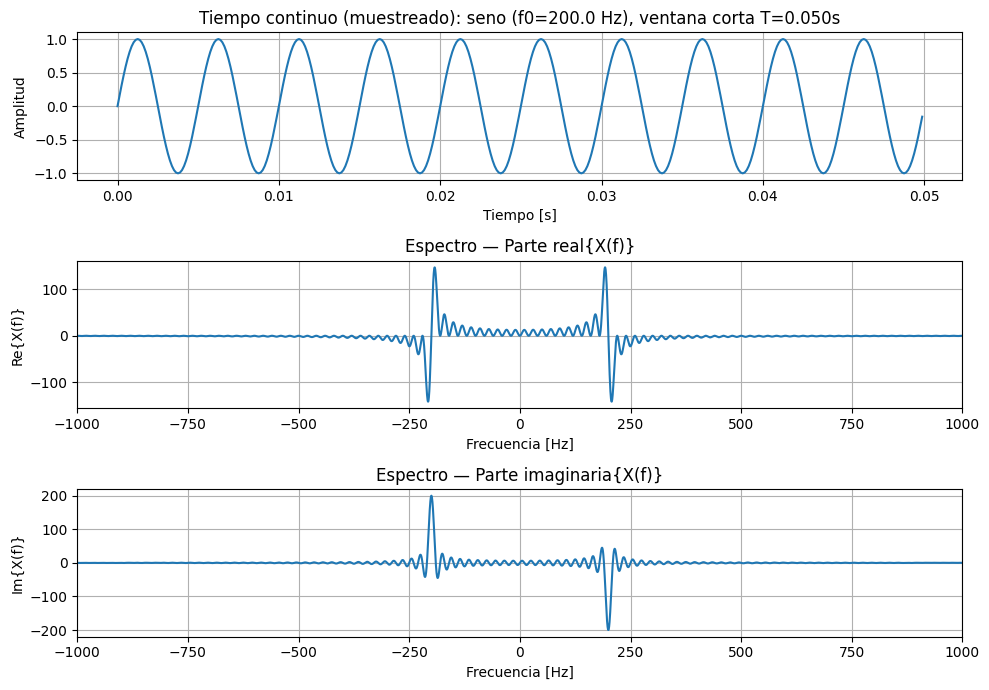

---





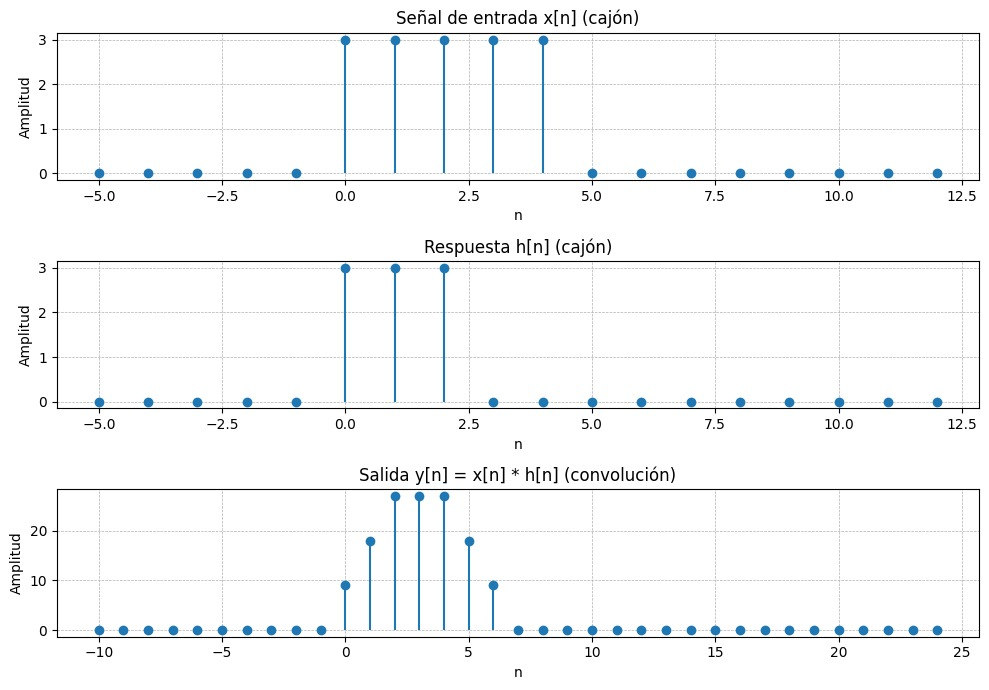

# Arquitectura de Sistemas de Transmisión y Recepción

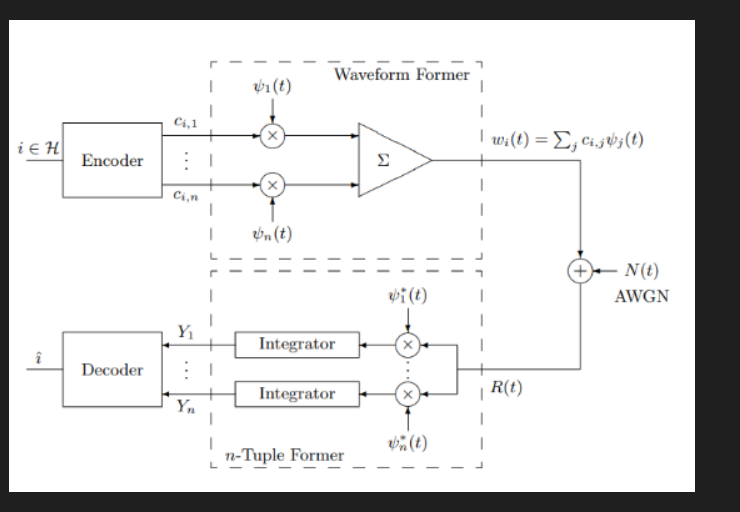

# Encoder

La entrada al encoder es un mensaje $i \in H$, este mensaje puede ser un bloque de $k$ bits.  

La salida del encoder asigna a cada mensaje $i$ un vector de coeficientes, llamado **codeword**:

$$
\mathbf{c}_i =
\begin{bmatrix}
c_{i,1} \\
c_{i,2} \\
\vdots \\
c_{i,n}
\end{bmatrix}
\in \mathbb{C}^n.
$$

Este vector es una representación matemática del mensaje dentro de un espacio de dimensión $n$.

---

# Waveform Former

El waveform former toma los coeficientes que salieron del encoder:

$$
\mathbf{c}_i = (c_{i,1}, c_{i,2}, \dots, c_{i,n})
$$

y los convierte en una señal física en el tiempo $w_i(t)$.

Para hacerlo, utiliza un conjunto de **funciones base ortonormales** definidas en el intervalo de símbolo $[0,T]$.


### Condición de ortonormalidad

Las funciones base cumplen:

$$
\langle \psi_j, \psi_k \rangle 
= \int_0^T \psi_j(t)\, \psi_k^*(t)\, dt = \delta_{jk}.
$$

Donde $\delta_{jk}$ vale 1 si $j=k$ y 0 si $j \neq k$.

Esto significa que cada función componente de la base es ortogonal a las demás y tiene energía unitaria.  

Esta condición es fundamental porque garantiza que, más adelante en el receptor, cada componente se podrá recuperar de manera independiente (sin interferencia entre ellas).


### Señal transmitida

La señal transmitida es una suma ponderada de las funciones base:

$$
w_i(t) = \sum_{j=1}^{n} c_{i,j}\, \psi_j(t).
$$

Cada coeficiente del codeword determina qué tanta importancia tiene su función base en la señal final.  

El waveform former convierte así un vector de coeficientes en una onda continua en el tiempo.

---

# Canal AWGN

En el modelo de comunicación, el canal se considera como un **canal con ruido aditivo blanco gaussiano (AWGN, Additive White Gaussian Noise)**.  

Matemáticamente, la señal recibida es:

$$
r(t) = w_i(t) + n(t),
$$

donde:

- $w_i(t)$ es la señal transmitida (salida del *waveform former*).  
- $n(t)$ es el ruido AWGN, un proceso aleatorio con las siguientes características:

### Propiedades del AWGN

1. **Aditivo:** el ruido se suma linealmente a la señal transmitida.  
2. **Blanco:** posee densidad espectral de potencia constante en todas las frecuencias, es decir, afecta por igual a todo el espectro de la señal.  
3. **Gaussiano:** sus muestras siguen una distribución normal de media cero y varianza $\sigma^2$:  
   $$
   n(t) \sim \mathcal{N}(0, \sigma^2).
   $$

El canal AWGN se encarga de **degradar la señal transmitida** al sumar ruido gaussiano blanco, y constituye la base para analizar la confiabilidad del sistema de comunicación.

---

# n-Tuple Former

Después de que la señal transmitida $w_i(t)$ atraviesa el canal AWGN, la señal recibida es:

$$
r(t) = w_i(t) + n(t),
$$

es decir, la señal deseada más el ruido.

El bloque **n-Tuple Former** tiene como objetivo **reconvertir la señal continua recibida en un vector de coeficientes**, de forma análoga al codeword generado por el encoder en el transmisor.


### Proyección sobre funciones base

El receptor dispone de las mismas funciones base ortonormales $\psi_j(t)$ que se usaron en el transmisor.  
Se proyecta $r(t)$ sobre cada función base mediante un integrador:

$$
Y_j = \int_0^T r(t)\,\psi_j^*(t)\,dt.
$$

De esta manera se obtiene un conjunto de valores $(Y_1, Y_2, \dots, Y_n)$.

### Recuperación de los coeficientes

Gracias a la ortogonalidad, si no hubiera ruido se cumpliría:

$$
Y_j = c_{i,j}.
$$

Con ruido, en cambio:

$$
Y_j = c_{i,j} + \eta_j,
$$

donde $\eta_j$ representa el efecto del ruido proyectado sobre la función base $\psi_j(t)$.


### Formación del vector recibido

El conjunto de salidas forma el vector:

$$
\mathbf{Y} = (Y_1, Y_2, \dots, Y_n),
$$

que es una versión **ruidosa** del codeword original $\mathbf{c}_i$.


El **n-Tuple Former** convierte la señal recibida $r(t)$ en un vector de dimensión $n$, que luego se entrega al **decoder**.  
Este último se encarga de decidir cuál era el mensaje transmitido comparando $\mathbf{Y}$ con los posibles codewords.

---

# Decoder

El **decoder** recibe del *n-Tuple Former* el vector:

$$
\mathbf{Y} = (Y_1, Y_2, \dots, Y_n),
$$

el cual es una versión ruidosa del codeword transmitido.


### Comparación con codewords posibles

El decoder conoce todos los codewords $\mathbf{c}_i$ que corresponden a los mensajes válidos.  
Su tarea es comparar $\mathbf{Y}$ con cada uno de ellos.


### Criterio de decisión

Generalmente se utiliza el criterio de **máxima verosimilitud (ML)** o de **mínima distancia euclídea**:

$$
\hat{i} = \arg \min_i \|\mathbf{Y} - \mathbf{c}_i\|^2
$$

Es decir, se elige el codeword más cercano al vector recibido.


### Estimación del mensaje

El índice $\hat{i}$ obtenido corresponde al mensaje estimado por el decoder.  

- **Sin ruido:** se cumple $\mathbf{Y} \approx \mathbf{c}_i$ y la detección es exacta.  
- **Con ruido:** el vector $\mathbf{Y}$ puede desplazarse hacia otro codeword, provocando un error de decodificación.  



### Influencia del ruido

La probabilidad de error depende de:

- La **relación señal-ruido (SNR)** en el canal.  
- La **distancia entre codewords** en el espacio de dimensión $n$.  


El **decoder** toma el vector recibido $\mathbf{Y}$, lo compara con todos los codewords posibles y selecciona el más cercano.  
De esta forma reconstruye el mensaje transmitido con la mayor probabilidad de acierto.


# Prefijo Cíclico (CP)

## Introducción

El **prefijo cíclico (CP)** es una técnica usada en sistemas multiportadora que consiste en anteponer una copia de la porción final de un símbolo OFDM al inicio del mismo. Desde el punto de vista temporal es un segmento extra de muestras que se transmite antes de la parte útil del símbolo. El CP no contiene nueva información útil por sí mismo: su propósito es modificar cómo interactúa la señal con el canal físico, simplificando la estructura de la distorsión que el canal introduce.

## Definición

Sea $x[n]$ un símbolo OFDM de longitud $K$, indexado desde $n=0$ hasta $n=K-1$. Sea $N_{CP}$ la longitud en muestras del prefijo cíclico. El símbolo transmitido con CP, $x_{CP}[n]$, tiene longitud $K+N_{CP}$ y se define como:

- Para $n=0,1,\dots,N_{CP}-1$:
  $$
  x_{CP}[n] = x[n+K-N_{CP}]
  $$
- Para $n=N_{CP},\dots,N_{CP}+K-1$:
  $$
  x_{CP}[n] = x[n-N_{CP}]
  $$

## Propiedades matemáticas y consecuencias

### Conversión de convolución lineal a convolución circular

Si el canal discreto tiene respuesta al impulso $h[n]$ de longitud $L_h$, y si se cumple

$$
N_{CP} \ge L_h - 1,
$$

entonces, al recibir el símbolo y eliminar el CP, la operación que liga la parte útil transmitida con la porción útil recibida es equivalente a una **convolución circular** entre el vector símbolo y la respuesta al impulso. La conversión es la siguiente:

- Sin CP, la señal útil recibida sería el resultado de una convolución lineal que mezcla símbolos adyacentes.
- Con CP suficientemente largo, la porción útil del símbolo recibido es igual a la convolución circular del símbolo útil por una versión del canal, lo cual permite diagonalizar la operación mediante la DFT/FFT.

Esta propiedad es la que permite tratar cada subportadora de forma independiente en frecuencia: la FFT transforma la convolución circular en una multiplicación punto a punto en frecuencia.

### Estabilidad temporal y repetición cíclica

El prefijo cíclico reproduce el final del símbolo al principio, por lo que los saltos de fase o cambios en la envolvente que ocurren dentro del CP no afectan al bloque útil: actúa como un amortiguador temporal de los ecos más largos del canal.

## Interpretación física

- El canal multipath produce réplicas retrasadas y atenuadas del símbolo transmitido. Si las réplicas llegan dentro del intervalo del CP, estas se superponen sólo con el CP y no con la porción útil del símbolo.
- Al eliminar el CP en el receptor, la porción útil restante está libre de interferencia de símbolos anteriores, siempre que la condición $N_{CP} \ge L_h - 1$ se cumpla.

## Costes y limitaciones

1. **Pérdida de eficiencia espectral:** el CP no transmite información nueva, por lo que reduce la tasa neta útil. La fracción de overhead es:

$$
\text{Overhead} = \frac{N_{CP}}{N_{CP} + K}.
$$

2. **Consumo de potencia:** al transmitir símbolos más largos, la energía transmitida por bit se ve afectada si la energía por símbolo se mantiene constante.

3. **Elección de longitud:** un CP demasiado corto permite ISI; uno demasiado largo penaliza severamente la eficiencia. Es un compromiso entre robustez frente a la dispersión del canal y eficiencia espectral.

4. **No resuelve todas las distorsiones:** el CP no corrige desajustes de frecuencia, desvanecimientos selectivos extremos ni cambios rápidos del canal dentro del símbolo útil.


---

# Simulación OFDM

**Objetivo:** mostrar la implementación por bloques del sistema OFDM.
Aquí usamos QPSK normalizado, `K` portadoras y `n` símbolos.

---

## Librerías
En esta celda solo importamos las librerías necesarias. 

In [11]:
import numpy as np
import matplotlib.pyplot as plt

---

## Parámetros
En esta celda definimos los parametros globales utilizados para la ejecución del codigo.

In [12]:
# ========================= PARÁMETROS GLOBALES =========================
K = 64                           # cantidad de portadoras.
N = 10                           # número inicial de símbolos OFDM. Cambia según la cantidad de bits pedidos por consola.
BitsPorSimbolo = 2               # QPSK -> 2 bits por portadora.
np.set_printoptions(threshold=10000, linewidth=200)

# DF_TRUE: offset de frecuencia aplicado en el transmisor.
DF_TRUE = 0.01

# Respuesta al impulso del canal.
RespuestaImpulsoCanal = np.array([1.0], dtype=complex)

# CP fijo que se usará en toda la simulación. Debe cumplir 0 <= ValorCP < K
ValorCP = 16

# Número de tramas solicitadas por iteración, se ajusta si no divide N.
TramasPorIterSolicitadas = 4

# Símbolos OFDM de silencio entre tramas.
SimbolosSilencio = 5

# Umbral para detección directa de la meseta.
UmbralDeteccionPreambulo = 0.08

---

# Encoder en OFDM

## Mapeo QPSK
En QPSK cada símbolo lleva 2 bits. Una convención de mapeo Gray común es:

Bits -> Punto complejos (sin normalizar)

00 -> 1 + j

01 -> 1 - j

11 -> -1 - j

10 -> -1 + j


Con este mapeo dos símbolos adyacentes difieren en un solo bit, lo que reduce la probabilidad de errores bit cuando un símbolo se confunde por ruido.

## Normalización teórica de la constelación
Los puntos anteriores tienen energía igual a $|1\pm j|^2 = 2$. Para fijar la energía por símbolo a $E_s = 1$, se divide cada símbolo por $\sqrt{2}$. Es decir, el símbolo normalizado asociado a un punto $s\in\{1\pm j,-1\pm j\}$ es
$
s_{\text{norm}} = \frac{s}{\sqrt{2}}.
$
Con esto claramente $|s_{\text{norm}}|^2 = 1$ para cada punto de la constelación.

## Media
La **media** de un conjunto de símbolos complejos $\{X_i\}_{i=1}^N$ mide el centro de masa de la constelación y se estima como
$
\hat{\mu} \;=\; \frac{1}{N}\sum_{i=1}^N X_i.
$
Interpretación práctica:
- Si $\hat\mu \neq 0$ hay una componente DC en la señal.  
- Una componente DC consume potencia sin transmitir información útil y puede causar un error en el dominio de la frecuencia.

## Varianza
La **varianza** se estima por
$
\widehat{\mathrm{Var}} \;=\; \frac{1}{N}\sum_{i=1}^N |X_i - \hat\mu|^2.
$
Interpretación práctica:
- Para una constelación QPSK normalizada teóricamente se espera $\widehat{\mathrm{Var}}\approx 1$.  
- Si la varianza estimada difiere significativamente de 1, la potencia real enviada no coincide con la potencia teórica, lo que descalibra la relación señal-ruido (SNR) y perjudica comparaciones con curvas teóricas.


In [13]:
def Encoder(K_local, NumeroSimbolos):
    """
    Genera bits aleatorios y mapea a QPSK normalizada (energía por símbolo = 1).
    - num_bits = BitsPorSimbolo * K_local * NumeroSimbolos
    - BitsTx: array 1D de bits (0/1)
    - Xmat: matriz (NumeroSimbolos x K_local) con símbolos complejos QPSK
    - stats: diccionario con media y varianza empíricas de Xmat (útil para debug/registro)
    """
    num_bits = BitsPorSimbolo * K_local * NumeroSimbolos
    BitsTx = np.random.randint(0, 2, size=num_bits)
    bits_reshaped = BitsTx.reshape(NumeroSimbolos, K_local, BitsPorSimbolo)
    bI = bits_reshaped[:, :, 0]
    bQ = bits_reshaped[:, :, 1]
    Xmat = (1 - 2*bI) + 1j * (1 - 2*bQ)   # mapeo duro QPSK: 0->+1, 1->-1
    Xmat = Xmat / np.sqrt(2)              # normalización para energía 1
    mu_before = np.mean(Xmat)
    var_before = np.mean(np.abs(Xmat - mu_before)**2)
    stats = {'media_empirica': mu_before, 'varianza_empirica': var_before}
    return BitsTx, Xmat, stats

---
# Waveform Former en OFDM 

### Concepto
- El *waveform former* recibe una **matriz de símbolos en frecuencia**.  
- Aplica una **IFFT** para obtener la **señal temporal OFDM**, que es la suma de portadoras ortogonales moduladas con sus símbolos.  
- Cada portadora es una onda compleja de la forma:

$$
\psi_k[n] = e^{j 2\pi \frac{k}{N} n}, \quad k = 0,1,\dots,N-1.
$$

- La ortogonalidad de estas portadoras garantiza que, en el receptor, una FFT puede recuperar cada símbolo sin interferencia entre portadoras (**sin ICI**).

### IFFT ortonormal
Se utiliza la versión ortonormal de la IFFT porque mantiene la energía del símbolo OFDM y hace que la operación inversa sea perfectamente simétrica respecto de la FFT. Esto evita factores de escala adicionales y simplifica el análisis de potencia y ortogonalidad.

La IFFT ortonormal de un bloque en frecuencia $X[k]$ está dada por:

$$
x[n] = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} X[k] \, e^{j 2\pi \frac{k n}{N}} ,\quad n=0,\dots,N-1 
$$


### Demostración de ortogonalidad de portadoras

Queremos verificar que las funciones base $\psi_k[n]$ son ortogonales en un intervalo de $N$ muestras:

$$
\langle \psi_k, \psi_q \rangle = \sum_{n=0}^{N-1} \psi_k[n] \, \psi_q^*[n].
$$

Sustituyendo:

$$
\langle \psi_k, \psi_q \rangle
= \sum_{n=0}^{N-1} e^{j 2\pi \frac{k-q}{N}n}.
$$


### Caso 1: $k = q$

$$
\langle \psi_k, \psi_k \rangle = \sum_{n=0}^{N-1} 1 = N.
$$

Cada portadora tiene energía $N$.


### Caso 2: $k \neq q$

La suma es una serie geométrica:

$$
\langle \psi_k, \psi_q \rangle
= \frac{1 - e^{j 2\pi (k-q)}}{1 - e^{j 2\pi \frac{(k-q)}{N}}}.
$$

Como $e^{j 2\pi (k-q)} = 1$, el numerador se anula:

$$
\langle \psi_k, \psi_q \rangle = 0, \quad k \neq q.
$$

Por lo que las portadoras cumplen:

$$
\langle \psi_k, \psi_q \rangle =
\begin{cases}
N, & k = q, \\
0, & k \neq q.
\end{cases}
$$

Esto demuestra que son **ortogonales en el intervalo de símbolo OFDM**.  

### Prefijo cíclico (CP)

- El prefijo cíclico es una copia de las últimas muestras del bloque temporal que se antepone al inicio del mismo antes de la transmisión.  
- Su objetivo esencial es proteger al bloque útil frente a la dispersión temporal introducida por el canal: si la duración del prefijo es al menos tan larga como la dispersión temporal del canal, la convolución lineal del canal con la señal dentro del intervalo útil se comporta efectivamente como una **convolución circular**.  
- Esa conversión a convolución circular es crucial porque la FFT diagonaliza la convolución circular; en consecuencia, en el dominio de la frecuencia el canal actúa sobre cada portadora como una simple multiplicación por un complejo, y no como una mezcla entre portadoras. Esto permite la ecualización por portadora de forma independiente y simple.  
- En el *waveform former* se agrega el CP copiando las últimas $N_{CP}$ muestras del bloque temporal (resultado de la IFFT) y pegándolas al principio del bloque antes de concatenar los símbolos para transmisión. Se hace esto porque:
  - Es necesario preservar la relación circular necesaria para que la FFT en el receptor recupere correctamente cada portadora.
  - Facilita que la extracción del símbolo útil en el receptor sea simplemente eliminar las $N_{CP}$ primeras muestras antes de aplicar FFT.

In [14]:
def WaveformFormer(Xmat_local, K_local, N_cp_local):
    """
    Convierte símbolos en frecuencia (fila por fila) a tiempo usando IFFT ortho,
    y agrega CP de longitud N_cp_local a cada fila.
    - Si N_cp_local == 0 devuelve solo los símbolos en tiempo (sin CP).
    - Devuelve una matriz (m x (K_local + N_cp_local)) con cada fila = CP | símbolo.
    """
    s_time = np.fft.ifft(Xmat_local, n=K_local, axis=1, norm='ortho')  # IFFT por fila
    if N_cp_local == 0:
        return s_time
    s_with_cp = np.zeros((s_time.shape[0], K_local + N_cp_local), dtype=complex)
    s_with_cp[:, :N_cp_local] = s_time[:, -N_cp_local:]   # copiar último N_cp_local como CP
    s_with_cp[:, N_cp_local:] = s_time
    return s_with_cp

---

# Canal en OFDM: modelo ideal con ruido AWGN

Una vez que la señal está normalizada en el encoder, pasa por el canal. En este caso se considera:

## Canal ideal
- No altera la señal transmitida.  
- Respuesta al impulso:

$$
h(t) = \delta(t).
$$

- Respuesta en frecuencia:

$$
H(f) = 1, \quad \forall f.
$$

- En ausencia de ruido:

$$
y[n] = s[n].
$$

## Inclusión de ruido AWGN
En la práctica, el canal añade ruido gaussiano complejo:

$$
y[n] = s[n] + w[n],
$$

donde $w[n]$ es una variable aleatoria compleja con:
- **Media cero:** el ruido no introduce desplazamiento sistemático.  
- **Varianza $\sigma_w^2$:** controla la potencia del ruido.  

El ruido complejo se modela como:

$$
w[n] = w_{\text{re}}[n] + j\,w_{\text{im}}[n],
$$

con $w_{\text{re}}$ y $w_{\text{im}}$ gaussianos independientes de varianza $\sigma_w^2/2$.

## Relación con la SNR
La SNR se define como la razón entre la potencia de la señal y la potencia del ruido:

$$
\mathrm{SNR} = \frac{E_s}{\sigma_w^2}.
$$

Si en el encoder se normalizó la potencia de símbolo a $E_s=1$:

$$
\sigma_w^2 = \frac{1}{\mathrm{SNR}}.
$$

En dB:

$$
\sigma_w^2 = 10^{-\mathrm{SNR_{dB}}/10}.
$$

De esta manera, el nivel de ruido añadido puede ajustarse exactamente según la SNR deseada.

## Resultado del canal
- El canal entrega la señal OFDM recibida como la señal transmitida más ruido aditivo gaussiano.  
- Gracias a la normalización previa en el encoder, la SNR se controla de forma precisa.



In [15]:
def Canal(x_total, snr_lin, h):
    """
    Modelo de canal lineal + AWGN en flujo continuo:
    - x_total: trama aplanada
    - h: respuesta al impulso del canal
    - snr_lin: Es/N0 lineak
    Devuelve:
      r_total: señal recibida
      y_conv_total: convolución limpia sin ruido
      PotenciaSenal: potencia empírica de la señal
      Sigma2: varianza del ruido complejo
    """
    Lh = len(h)
    y_conv_total = np.convolve(x_total, h, mode='full')   # convolución lineal
    mu_emp = np.mean(y_conv_total)
    y_zero_mean = y_conv_total - mu_emp
    PotenciaSenal = np.mean(np.abs(y_zero_mean)**2)
    if PotenciaSenal <= 0:
        PotenciaSenal = 1e-12
    Sigma2 = PotenciaSenal / snr_lin
    noise_re = np.random.randn(*y_conv_total.shape) * np.sqrt(Sigma2 / 2.0)
    noise_im = np.random.randn(*y_conv_total.shape) * np.sqrt(Sigma2 / 2.0)
    noise = noise_re + 1j * noise_im
    r_total = y_conv_total + noise
    return r_total, y_conv_total, PotenciaSenal, Sigma2

---

# n-Tuple Former en OFDM

El n-Tuple Former recibe la señal en el dominio temporal organizada en bloques de $N$ muestras (cada bloque corresponde a un símbolo OFDM) y aplica FFT ortonormal para que constituya la inversa exacta de la IFFT anterior.

La FFT ortonormal de un bloque temporal $x[n]$ se define como:

$$ 
X[k] = \frac{1}{\sqrt{N}} \sum_{n=0}^{N-1} x[n] \, e^{-j 2\pi \frac{k n}{N}} ,\quad k=0,\dots,N-1 
$$

## Relación transmisión–recepción
En el transmisor, el símbolo temporal se generó como:

$$
x[n] = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} X[k] \, e^{j 2\pi \frac{k n}{N}}.
$$

En el canal ideal con ruido:

$$
y[n] = x[n] + w[n].
$$

Al aplicar la FFT en el receptor, considerando el efecto del canal:

$$
Y[k] = X[k]\,H[k] + W[k].
$$

## Ortogonalidad de las portadoras
El resultado perfecto se logra porque las portadoras son ortogonales en el intervalo de $N$ muestras:

$$
\sum_{n=0}^{N-1} e^{j 2\pi \frac{(k-q)}{N} n} =
\begin{cases}
N, & k=q, \\
0, & k \neq q.
\end{cases}
$$

Esto garantiza que, al aplicar la FFT, cada portadora se proyecta solo sobre sí misma y no hay interferencia entre ellas (**no existe ICI**).

## Quitar el CP en el n-Tuple Former  
El n-Tuple Former extrae de cada ventana temporal únicamente las $K$ muestras útiles del símbolo OFDM, eliminando previamente el prefijo cíclico (CP).  
La extracción comienza en el índice donde finaliza el CP y comienza la parte útil.  
Esto es necesario porque la FFT debe aplicarse únicamente sobre el bloque de $K$ muestras que mantiene la ortogonalidad entre portadoras; el CP no forma parte del intervalo útil y no debe entrar en la FFT.

### Condición del CP  
Para que la eliminación del CP sea válida y el símbolo útil mantenga ortogonalidad, el prefijo cíclico debe cumplir:

$
N_{CP} \ge L_h - 1,
$

donde $L_h$ es la longitud efectiva de la respuesta impulsiva del canal.  
Si esta condición se cumple, la convolución lineal entre el símbolo OFDM y el canal se vuelve circular dentro del intervalo útil.  
Esto garantiza que, al aplicar la FFT, cada portadora se ve afectada sólo por una multiplicación compleja sin generar interferencia entre portadoras (ICI).  
Si el CP es más corto que la dispersión temporal del canal, aparecen ISI e ICI, degradando la recuperación en frecuencia.


In [ ]:
def nTupleFormer(y_rows_after_channel, K_local, start_idx_list):
    """
    Quita CP usando los start_idx dados y aplica FFT ortho por fila.
    - y_rows_after_channel: lista de ventanas temporales (cada una puede tener longitud variable)
    - start_idx_list: índices dentro de cada ventana donde empiezan las K muestras útiles (sin CP)
    - Si la ventana no tiene suficientes muestras, NO se rellena con ceros: esa ventana se
      omite completamente (no produce fila en la salida).
    - Devuelve Ymat: matriz (n_rows x K_local) con FFT por fila.
    """
    Y_list = []
    for y_row, start in zip(y_rows_after_channel, start_idx_list):
        # índice inicial y final de las K muestras útiles dentro de la ventana
        s = int(start)
        end = s + K_local
        # rechazamos ventanas que no contengan las K muestras completas
        if s < 0 or end > y_row.size:
            # omitimos esta ventana
            continue
        # extraemos exactamente K muestras y aplicamos FFT ortho
        y_useful = y_row[s:end]
        Y = np.fft.fft(y_useful, n=K_local, norm='ortho')
        Y_list.append(Y)
    if len(Y_list) == 0:
        return np.zeros((0, K_local), dtype=complex)
    Ymat = np.vstack(Y_list)
    return Ymat

---

# Decoder en OFDM

## Contexto general
En un receptor OFDM, tras aplicar la FFT al bloque de muestras de tiempo se obtiene una matriz de coeficientes en frecuencia $Y[k]$. Cada entrada $Y[k]$ contiene la contribución del símbolo transmitido $X[k]$ afectada por el canal y por el ruido:
$Y[k] = H[k]\,X[k] + W[k],$
donde $H[k]$ es la respuesta en frecuencia del canal en la portadora $k$ y $W[k]$ es el ruido.

Para recuperar los bits se realiza el proceso en dos etapas: **ecualización** y **demapeo**.

## Ecualizador
### Objetivo
Compensar el efecto del canal $H[k]$ sobre cada portadora para estimar los símbolos transmitidos $X[k]$ a partir de las observaciones $Y[k]$.

### Modelos de ecualización comunes
- **Zero-Forcing (ZF):** la estimación se obtiene dividiendo por la respuesta estimada del canal:
  $$
  \hat{X}_{\text{ZF}}[k] = \frac{Y[k]}{\hat{H}[k]}.
  $$
  ZF cancela la distorsión del canal pero puede aumentar la contribución del ruido cuando $|\hat{H}[k]|$ es pequeño.

- **Minimum Mean Square Error (MMSE):** busca minimizar el error cuadrático medio, ponderando canal y ruido:
  $$
  \hat{X}_{\text{MMSE}}[k] = \frac{\hat{H}^*[k]}{|\hat{H}[k]|^2 + \frac{N_0}{E_s}}\,Y[k],
  $$
  donde $N_0$ es la densidad espectral del ruido y $E_s$ la energía por símbolo. MMSE ofrece un compromiso entre corrección de canal y amplificación del ruido.

## Demapper
### Objetivo
Convertir cada estimación compleja $\hat{X}[k]$ en los bits correspondientes según la constelación empleada.

### Demapeo duro para QPSK
Con QPSK, cada símbolo complejo se asigna a dos bits. La decisión dura es por signo de las componentes real e imaginaria:
- bit asociado a la componente real:
  $$
  \text{bit}_I = 
  \begin{cases}
  0, & \Re\{\hat{X}[k]\} \ge 0,\\[2pt]
  1, & \Re\{\hat{X}[k]\} < 0,
  \end{cases}
  $$
- bit asociado a la componente imaginaria:
  $$
  \text{bit}_Q = 
  \begin{cases}
  0, & \Im\{\hat{X}[k]\} \ge 0,\\[2pt]
  1, & \Im\{\hat{X}[k]\} < 0.
  \end{cases}
  $$

Este demapeo corresponde a una asignación con codificación Gray.

In [17]:
def Ecualizador(Ymat, Hhat):
    """
    Ecualizador simple: división por Hhat (estimación del canal por subportadora).
    - Aquí Hhat = 1 (ideal) por simplicidad en la simulación base.
    """
    return Ymat / Hhat


def Demapper(Xhat):
    """
    Demapeo duro QPSK: decisión por signo en I y Q.
    - Entrada Xhat: matriz (n_sym x K)
    - Salida BitsRx: vector 1D (0/1) en el orden de mapeo original.
    """
    if Xhat.size == 0:
        return np.zeros(0, dtype=int)
    bitI = (np.real(Xhat) < 0).astype(int)
    bitQ = (np.imag(Xhat) < 0).astype(int)
    n_sym, K_local = Xhat.shape
    BitsRx = np.stack((bitI, bitQ), axis=2).reshape(n_sym * K_local * 2)
    return BitsRx

# Descripción del flujo de simulación OFDM

## Construcción del preámbulo repetitivo STF
- Se diseña un preámbulo en el dominio temporal formado por un bloque corto que se repite dos veces.
- La repetición crea una estructura con gran autocorrelación entre segmentos consecutivos, que es aprovechable para detectar la presencia de una trama y estimar desfases de frecuencia a baja complejidad.

## Generación aleatoria de bits y mapeo a símbolos, codificación y modulación
- Se generan secuencias binarias aleatorias representando información.
- Cada conjunto de bits se mapea a un **símbolo QPSK**, con normalización de energía para mantener referencia de potencia.
- La matriz de símbolos en frecuencia organiza los símbolos por **símbolo OFDM** en filas y por portadora en columnas.

## Formación de la forma de onda OFDM, IFFT y prefijo cíclico
- Cada **símbolo OFDM** en frecuencia se convierte a tiempo aplicando una transformada inversa discreta por símbolo.
- Tras la IFFT se antepone una copia de las últimas muestras del símbolo temporal, el prefijo cíclico.
- El prefijo cíclico protege el símbolo útil de la dispersión temporal del canal, si su duración es suficiente respecto a la respuesta impulsiva del canal, la convolución lineal se comporta como convolución circular sobre la parte útil, esto permite que la FFT en el receptor diagonalice el efecto del canal por portadora.

## Construcción de la trama, preámbulo seguido de símbolos
- Una trama típica concatena el preámbulo temporal con una secuencia de **símbolos OFDM**, cada uno con su prefijo cíclico.
- Esta trama se transmite por el canal y es la unidad que el receptor intenta detectar y procesar.

## Canal ideal con ruido AWGN
- El canal se modela como un sistema lineal invariante en el tiempo durante la duración de la trama, representado por una respuesta impulsiva finita.
- La señal transmitida sufre la convolución lineal con esa respuesta impulsiva y se corrompe con ruido aditivo gaussiano blanco complejo.
- En la simulación se cuantifica la potencia efectiva de la señal recibida y se ajusta la varianza del ruido para obtener la relación señal a ruido deseada, la cual condiciona el rendimiento medido en BER.

## Detección de inicio de trama basada en autocorrelación
- Para localizar el preámbulo repetitivo se calcula una métrica que compara segmentos separados por la longitud de repetición, se suma el producto complejo entre cada par de segmentos repetidos y se normaliza por la energía local.
- Esta métrica, al estar normalizada por energía, es robusta frente a variaciones de amplitud, produce picos donde hay coherencia de fase entre repeticiones y por tanto la presencia del preámbulo.
- El detector devuelve un vector de posiciones candidatas con su métrica asociada.

## Identificación de mesetas
- En la serie de la métrica se buscan intervalos contiguos donde la métrica supera un umbral.
- Las mesetas representan ventanas temporales donde existe repetición coherente y por tanto probabilidad alta de preámbulo.
- De las mesetas detectadas se selecciona típicamente la más significativa según criterios como ancho o área suma de la métrica para elegir la región más fiable.

## Estimador de timing basado en repetición
Sea $r[n]$ la señal recibida. Para detectar la repetición del STF se correlacionan segmentos separados por $\tau_s$ muestras, cada uno de longitud $L$:

- Producto cruzado:
  $$
  P(d) = \sum_{n=0}^{L-1} r^*(d+n)\, r(d+n+\tau_s)
  $$

- Energía para normalizar:
  $$
  R(d) = \sum_{n=0}^{L-1} |r(d+n+\tau_s)|^2
  $$

- Métrica:
  $$
  M(d) = \frac{|P(d)|^2}{[R(d)]^2}.
  $$

Interpretación:
- $M(d)$ es pequeño cuando no hay repetición coherente.
- Cuando los segmentos corresponden al bloque corto repetido del STF, $M(d)$ sube.
- Debido al CP y al canal se forma una meseta donde $M(d)$ permanece alto.

La meseta permite:
- detección robusta,
- tolerancia a errores de sincronización,
- promediado para mejorar la estimación de CFO coarse.

## Estimación coarse del CFO
Si hay un desplazamiento de frecuencia $\Delta f$, la fase cambia linealmente:

$$
\Delta \phi \approx 2\pi\, \Delta f \cdot \tau.
$$

Tomando la fase de $P(d)$:

- Fase:
  $$
  \hat\phi = \arg(P(d))
  $$

- Estimación:
  $$
  \hat{\Delta f}_\text{coarse} = \frac{\hat\phi}{2\pi\, \tau}.
  $$

Rango válido de la estimación:

$$
|\Delta f| < \frac{1}{2\tau}.
$$

## Rol del CP y la meseta
- El CP hace que múltiples posiciones de inicio produzcan la misma parte útil del símbolo OFDM, lo cual genera una meseta.
- La meseta mejora la robustez de la detección y permite promediar la fase en varios $d$, reduciendo la varianza del estimador de CFO.
- Si $N_{CP}$ es demasiado corto frente al canal, la meseta se achica o desaparece, degradando tanto timing como CFO.

## Corrección multiplicativa temporal, aplicación de la estimación CFO
- Si la estimación coarse es confiable, se aplica una corrección multiplicativa sobre la señal recibida referenciada respecto al punto de timing seleccionado.
- Esa corrección atenúa gran parte del efecto de rotación de fase progresiva antes de extraer los símbolos, mejorando la recuperación por portadora.

## Ventaneo para extracción de símbolos y manejo de la cola del canal
- A partir del punto de referencia temporal se extraen ventanas que contienen el preámbulo y cada **símbolo OFDM**, incluyendo su prefijo y una porción adicional para cubrir la cola de la convolución.
- La extracción considera la duración útil y una porción adicional igual a la longitud de la respuesta impulsiva menos uno, esto permite capturar la cola de la convolución y alinear correctamente el símbolo dentro de la ventana.

## Eliminación del prefijo cíclico y transformada al dominio frecuencia
- Para cada ventana se descarta la porción correspondiente al prefijo cíclico y se aplica la FFT a las muestras útiles del símbolo temporal.
- Esta operación transforma de nuevo al dominio de portadoras, donde idealmente cada componente del vector resultante corresponde al **símbolo QPSK** transmitido en esa portadora multiplicado por el coeficiente complejo del canal más ruido.

## Manejo de ventanas incompletas, política de integridad de símbolo
- Si una ventana no contiene las muestras útiles completas por recorte en los bordes o por faltante de datos, se omite por completo la ventana incompleta y no se procesa ese símbolo, evitando sesgos artificiales pero reduciendo el número de símbolos recuperados.

## Apilado de símbolos y preparación para ecualización
- Las salidas de la FFT de los símbolos válidos se organizan en una matriz donde cada fila es un **símbolo OFDM** en frecuencia.
- Esta representación es adecuada para aplicar ecualización por portadora de forma vectorizada y para posteriores operaciones de demapeo y evaluación.

## Ecualización en frecuencia
- Dada una estimación de la respuesta del canal por portadora, se compensa la atenuación y rotación dividiendo cada símbolo por el coeficiente complejo estimado.
- La ecualización busca restaurar el **símbolo QPSK** transmitido antes del demapeo.

## Demapeo de símbolos a bits
- Tras la ecualización se procede al demapeo duro, cada punto complejo se asigna al **símbolo QPSK** más cercano.
- El demapeo recupera la secuencia de bits estimada a partir de la representación en frecuencia.

## Evaluación de desempeño
- La tasa de errores de bit BER se estima comparando los bits recuperados con los bits originalmente transmitidos.
- Para obtener curvas estadísticas representativas se realizan múltiples repeticiones Monte Carlo y se promedian los resultados para obtener la BER media y su desviación estándar en función de la relación señal ruido.


In [18]:
def ConstruirPreambuloSTF(K_local):
    """
    Construye un preámbulo tipo STF en tiempo SIN CP.
    - K_local: número de subportadoras (debe ser par).
    - Se construye una mitad en frecuencia con alternancia [1, -1, 1, -1, ...],
      luego IFFT ortho de la mitad y se repite esa mitad en tiempo dos veces
      para obtener la estructura repetida (STF-like).
    - Devuelve s_stf_time: vector complejo de longitud K_local (símbolo tiempo).
    """
    if K_local % 2 != 0:
        raise ValueError("K debe ser par para construir STF-like con dos mitades iguales.")
    K2 = K_local // 2
    mitad_freq = np.array([1.0 if (i % 2 == 0) else -1.0 for i in range(K2)], dtype=complex)
    a_half = np.fft.ifft(mitad_freq, n=K2, norm='ortho')   # IFFT ortho de la mitad
    s_stf_time = np.tile(a_half, 2)                         # repetir en el tiempo dos veces
    return s_stf_time

def DetectorSTF(r_vec, L, tau_s, step=1):
    """
    Detector tipo STF (métrica clásica):
    - Calcula P(d) = sum_{n=0..L-1} r[d+n] * conj(r[d+n+tau_s])
    - R(d)  = sum |r[d:n]|^2 + sum |r[d+tau_s:n]|^2  (energía local, normalización)
    - M(d)  = |P(d)|^2 / R(d)^2  (métrica de energía-normalizada)
    - Devuelve arrays: ds (posiciones d), P_vec, R_vec, M_vec
    - Nota: protección para denominadores 0 (se usan epsilon).
    """
    Ntot = len(r_vec)
    max_d = Ntot - (tau_s + L)
    if max_d < 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
    ds = np.arange(0, max_d + 1, step)
    P_list = []
    R_list = []
    for d in ds:
        a = r_vec[d : d + L]
        b = r_vec[d + tau_s : d + tau_s + L]
        P = np.sum(a * np.conjugate(b))
        # Normalizamos por energía (más robusto frente a variaciones de amplitud)
        R = np.sum(np.abs(a)**2) + np.sum(np.abs(b)**2)
        P_list.append(P)
        R_list.append(R)
    P_vec = np.array(P_list)
    R_vec = np.array(R_list)
    denom = (R_vec**2).copy()
    denom[denom == 0] = 1e-24
    M_vec = (np.abs(P_vec)**2) / denom
    return ds, P_vec, R_vec, M_vec


def find_mesetas(M_vec, d_positions, M_th, min_width):
    """
    Encuentra mesetas (intervalos contiguos) donde M_vec >= M_th.
    - Devuelve lista de tuplas (d_start, d_end, slice(indices)).
    - min_width: ancho mínimo (en índices de M_vec) para aceptar una meseta.
    """
    above = M_vec >= M_th
    mesetas = []
    if above.size == 0:
        return mesetas
    start = None
    for i, val in enumerate(above):
        if val and start is None:
            start = i
        elif not val and start is not None:
            end = i - 1
            if (end - start + 1) >= min_width:
                mesetas.append((d_positions[start], d_positions[end], slice(start, end+1)))
            start = None
    if start is not None:
        end = len(above) - 1
        if (end - start + 1) >= min_width:
            mesetas.append((d_positions[start], d_positions[end], slice(start, end+1)))
    return mesetas


def get_d0(M_vec_slice, d_slice_positions):
    """
    Política auxiliar (la usábamos antes): escoger el primer d dentro de la meseta
    donde M >= 0.5*M_max. NO es la política que vas a imponer si obligás a la mitad,
    pero la dejamos como helper.
    - Retorna (d0, idx_rel) o (None, None) si la slice está vacía.
    """
    if len(M_vec_slice) == 0:
        return None, None
    M_max = np.max(M_vec_slice)
    half = 0.5 * M_max
    for idx_rel, val in enumerate(M_vec_slice):
        if val >= half:
            return int(d_slice_positions[idx_rel]), idx_rel
    mid_idx = len(M_vec_slice) // 2
    return int(d_slice_positions[mid_idx]), mid_idx

def TablaYConstelacion():
    """
    Imprime la tabla de mapeo bits->símbolo y grafica la constelación QPSK.
    (Se mantiene por compatibilidad con tu flujo actual.)
    """
    raw_mapping = {
        '00': 1 + 1j,
        '01': -1 + 1j,
        '11': -1 - 1j,
        '10': 1 - 1j
    }
    norm = np.sqrt(2)
    mapping = {bits: val / norm for bits, val in raw_mapping.items()}
    print("Tabla de mapeo (bits -> símbolo complejo):")
    for bits, sym in mapping.items():
        print(f"  {bits}  ->  {sym.real:+.3f} {sym.imag:+.3f}j")
    plt.figure(figsize=(5,5))
    for bits, sym in mapping.items():
        plt.scatter(np.real(sym), np.imag(sym), s=120)
        plt.text(np.real(sym)+0.03, np.imag(sym)+0.03, bits, fontsize=12)
    plt.axhline(0, color='k', linewidth=0.5)
    plt.axvline(0, color='k', linewidth=0.5)
    plt.title('Constelación QPSK y tabla de mapeo')
    plt.xlabel('I')
    plt.ylabel('Q')
    plt.gca().set_aspect('equal', 'box')
    plt.grid(True)
    plt.show()


# ---------------------- ArmarTrama ----------------------
def ArmarTrama(preambulo_tiempo, s_time_sub):
    """
    Construye la trama aplanada: [preambulo (K) | OFDM1 (K+Ncp) | OFDM2 ...]
    - Devuelve x_total (1D) y data_mask (boolean array indicando OFDM de datos).
    - Nota: no retorna offsets conocidos del TX.
    """
    partes = []
    partes.append(preambulo_tiempo.copy())
    for r in range(s_time_sub.shape[0]):
        partes.append(s_time_sub[r, :])
    x_total = np.concatenate(partes)
    num_datos = s_time_sub.shape[0]
    data_mask = np.array([True] * num_datos)
    return x_total, data_mask


# ========================= Estimador coarse de CFO =========================
def EstimadorCFO(P_slice, R_slice, tau_s):
    """
    Estimador coarse de CFO usando P(d) sobre la meseta:
    - P_slice: valores complejos P(d) dentro de la meseta
    - R_slice: valores reales R(d) (energía) dentro de la meseta
    - tau_s: separación entre repeticiones (muestras)
    Salidas:
      - df_hat: estimación en cycles/sample (float)
      - phi_hat: fase estimada (radianes)
      - P_sum: suma ponderada compleja usada (se devuelve para diagnóstico)
      - ok_flag: True si la estimación supera umbrales de confianza
    Método:
      - P_sum = sum(P_slice * R_slice) / sum(R_slice)  (ponderación por energía local, normalizada)
      - phi_hat = angle(P_sum)
      - df_hat = phi_hat / (2π tau_s)   (nota: convención de signo depende de cómo se inyectó DF_TRUE)
      - ok_flag: magnitud de P_sum mayor que umbral absoluto y relativo a mean(R_slice)
    """
    if P_slice.size == 0:
        return 0.0, 0.0, 0+0j, False
    weights = R_slice.copy()
    sumw = np.sum(weights)
    if sumw == 0:
        weights = np.ones_like(weights)
        sumw = np.sum(weights)
    P_sum = np.sum(P_slice * weights) / sumw
    phi_hat = np.angle(P_sum)
    df_hat = - phi_hat / (2.0 * np.pi * float(tau_s))
    mag = np.abs(P_sum)
    meanR = np.mean(R_slice) if R_slice.size > 0 else 0.0
    ok_flag = (mag > 1e-6) and (mag > (1e-3 * meanR))
    return df_hat, phi_hat, P_sum, ok_flag

In [19]:
def RunMonteCarlo(snr_dB_vector, runs, h, N_cp, tramas_por_iter, simbolos_silencio, DF_TRUE):
    """
    Monte Carlo.
    - snr_dB_vector: lista de SNR (Es/N0) en dB
    - runs: iteraciones Monte Carlo por SNR
    - h: respuesta al impulso del canal
    - N_cp: longitud de CP
    - tramas_por_iter: cuantas tramas se transmiten por iteracion
    - simbolos_silencio: cantidad de símbolos de silencio transmitidos fuera de trama
    - DF_TRUE: CFO inyectado en Tx (cycles/sample) - se pasó como argumento por claridad
    Devuelve:
      - ber_means, ber_stds, all_bers_per_snr, ultima_info (dic con info de última iteración)
    """
    ber_means = []
    ber_stds = []
    all_bers_per_snr = []
    ultima_info = None

    NumeroSimbolosTotales = N
    simbolos_por_trama = NumeroSimbolosTotales // tramas_por_iter
    preambulo_tiempo = ConstruirPreambuloSTF(K)

    # parámetros del detector STF (coinciden con preámbulo)
    L = K // 2
    tau_s = K // 2
    min_meseta_width = max(1, N_cp)

    for snr_db in snr_dB_vector:
        snr_lin = 10 ** (snr_db / 10.0)
        print("\n" + "="*72)
        print(f"Simulando SNR = {snr_db:.3f} dB (lin={snr_lin:.3f})  |  DF_TRUE (Tx) = {DF_TRUE}")
        print("="*72)
        bers_this_snr = []

        for run in range(runs):
            # ---------------- 1) Generar trama (bits + símbolos en frecuencia) ----------------
            BitsTx, Xmat, stats = Encoder(K, NumeroSimbolosTotales)
            Y_acc_list = []           # acumulador de filas (símbolos) aceptadas por trama
            BitsTxAceptados = []      # acumulador de bits de tramas aceptadas
            PotenciaSenalUltima = None
            Sigma2Ultima = None

            # Recorrer tramas dentro de una iteración
            for t in range(tramas_por_iter):
                # Seleccionar subconjunto de símbolos para esta trama
                i0 = t * simbolos_por_trama
                i1 = i0 + simbolos_por_trama
                X_sub = Xmat[i0:i1, :]

                # Generar waveform en tiempo y agregar CP
                s_time_sub = WaveformFormer(X_sub, K, N_cp)

                # Armar trama concatenando preámbulo (sin CP) y símbolos con CP
                x_total, data_mask = ArmarTrama(preambulo_tiempo, s_time_sub)

                # ---------------- INYECCIÓN DE CFO EN TX (solo para pruebas) ----------------
                if DF_TRUE != 0.0:
                    n_tx = np.arange(len(x_total))
                    x_total = x_total * np.exp(1j * 2.0 * np.pi * DF_TRUE * n_tx)
                    # Para no spamear, imprimimos la inyección solo para run==0 y trama 0
                    if run == 0 and t == 0:
                        print(f"[run 0] Trama {t+1}/{tramas_por_iter}: Inyectado DF_TRUE={DF_TRUE} en Tx.")

                # ---------------- pasar trama por canal (convolución + AWGN) ----------------
                r_total, y_conv_total, PotenciaSenal, Sigma2 = Canal(x_total, snr_lin, h)
                PotenciaSenalUltima = PotenciaSenal
                Sigma2Ultima = Sigma2

                # ---------------- DETECTOR STF: calcular P(d), R(d), M(d) -------------------
                ds, Pvec, Rvec, Mvec = DetectorSTF(r_total, L=L, tau_s=tau_s, step=1)

                # Variables por trama (se usan después)
                detectado = False
                d0 = None
                df_hat = 0.0
                phi_hat = 0.0
                P_sum_used = 0+0j
                applied_correction = False

                # ------------------- si hay posiciones de M(d) calculadas --------------------
                if Mvec.size > 0:
                    # Encontrar mesetas usando el umbral global UmbralDeteccionPreambulo
                    mesetas = find_mesetas(Mvec, ds, M_th=UmbralDeteccionPreambulo, min_width=min_meseta_width)

                    # Si hay mesetas, elegir la "mejor" por longitud/área (heurística)
                    if len(mesetas) > 0:
                        best = None
                        best_len = -1
                        best_area = -1
                        for (d_start, d_end, sl) in mesetas:
                            length = sl.stop - sl.start
                            area = np.sum(Mvec[sl])
                            if length > best_len or (length == best_len and area > best_area):
                                best = (d_start, d_end, sl)
                                best_len = length
                                best_area = area
                        d_start, d_end, sl = best
                        M_slice = Mvec[sl]
                        ds_slice = ds[sl]

                        # -------- POLÍTICA: usar la MITAD de la meseta como punto de referencia ----
                        d0_mid = int(round((d_start + d_end) / 2.0))

                        # Validación energética local alrededor de d0_mid para evitar falsas detecciones
                        check_len = K + N_cp + len(h)
                        start_check = max(0, d0_mid)
                        end_check = min(len(r_total), d0_mid + check_len)
                        energy_local = np.mean(np.abs(r_total[start_check:end_check])**2)

                        # Impresión por trama solo para run == 0
                        if run == 0:
                            print("-"*60)
                            print(f"[run 0] Trama {t+1}/{tramas_por_iter} -> meseta seleccionada {d_start}..{d_end}")
                            print(f"         d0_mid = {d0_mid}, energy_local = {energy_local:.3e}")
                            # también mostramos medias relevantes para diagnóstico conciso
                            print(f"         mean(R) = {np.mean(Rvec[sl]):.3e}, mean(|P|) = {np.mean(np.abs(Pvec[sl])):.3e}")
                        # Si la energía local indica que hay señal:
                        if energy_local > 1e-16:
                            detectado = True
                            d0 = d0_mid  # usamos la mitad como timing reference (política obligada)

                            # -------- ESTIMADOR CFO sobre la meseta (P_slice, R_slice) ------------
                            P_slice = Pvec[sl]
                            R_slice = Rvec[sl]
                            df_hat, phi_hat, P_sum_used, ok_flag = EstimadorCFO(P_slice, R_slice, tau_s)

                            # Impresión resumida del estimador (solo run==0)
                            if run == 0:
                                print(f"         EstCFO: |P_sum|={np.abs(P_sum_used):.3e}, phi_hat={phi_hat:.3f} rad, df_hat={df_hat}, ok_flag={ok_flag}")

                            # Aplicar corrección multiplicativa referenciada a d0 (si ok_flag True)
                            if ok_flag:
                                n_idx = np.arange(len(r_total))
                                corr = np.exp(-1j * 2.0 * np.pi * df_hat * (n_idx - d0))
                                r_total = r_total * corr
                                applied_correction = True
                                if run == 0:
                                    print(f"         Corrección CFO APLICADA referenciada a d0_mid={d0}.")
                            else:
                                applied_correction = False
                                if run == 0:
                                    print(f"         Corrección CFO NO aplicada (estimador no confiable).")

                # Si no detectamos preámbulo, modelamos silencio y seguimos
                if not detectado:
                    if run == 0:
                        print(f"[run 0] Trama {t+1}/{tramas_por_iter}: PREÁMBULO NO DETECTADO -> trama ignorada.")
                    if simbolos_silencio > 0:
                        silence_concat = np.zeros((K + N_cp) * simbolos_silencio, dtype=complex)
                        _r_sil, _y_conv_sil, PotSil, Sigma2Sil = Canal(silence_concat, snr_lin, h)
                        if run == 0 and t == tramas_por_iter - 1:
                            print(f"         Silencio transmitido despues: PotSil={PotSil:.4e}, sigma2={Sigma2Sil:.3e}")
                    continue

                # ------------------- Extracción de ventanas por símbolo y FFT -----------------
                # Construimos ventanas temporales por cada símbolo (0=preambulo, 1..m=datos)
                m = s_time_sub.shape[0]
                windows = []
                start_idx_list = []
                for idx_sym in range(0, 1 + m):
                    if idx_sym == 0:
                        tx_off = 0
                        len_symbol = K
                    else:
                        tx_off = K + (idx_sym - 1) * (K + N_cp)
                        len_symbol = K + N_cp

                    # queremos extraer un tramo que cubra el símbolo completo más cola de canal
                    long_extract = len_symbol + len(h) - 1
                    rx_start = d0 + tx_off
                    rx_end = rx_start + long_extract

                    # si la ventana cae fuera de r_total o es parcial, la omitimos (sin padding)
                    # condiciones de rechazo:
                    # - inicio de la porción útil (start_idx relativo) debe ser >= 0 dentro de la ventana
                    # - la ventana debe contener las K muestras útiles completas a partir de start_idx
                    if rx_start < 0 or rx_end > len(r_total):
                        # omitimos esta ventana completa (no la añadimos)
                        continue

                    # construimos la ventana (completa)
                    window = r_total[rx_start:rx_end]

                    # start_idx (dentro de la ventana) donde comienzan las K muestras útiles
                    if idx_sym == 0:
                        start_idx = (len(h) - 1)
                    else:
                        start_idx = N_cp + (len(h) - 1)

                    # comprobación adicional: asegurarnos que la ventana tiene start_idx + K_local muestras
                    if start_idx < 0 or (start_idx + K) > window.size:
                        # omitimos por seguridad
                        continue

                    windows.append(window)
                    start_idx_list.append(int(start_idx))


                # Quitar CP (usando start_idx_list) y FFT por fila
                Y_sub = nTupleFormer(windows, K, start_idx_list)

                # Si hay filas de datos (descartamos fila 0 = preámbulo), apilamos
                if Y_sub.size > 0:
                    if Y_sub.shape[0] > 1:
                        Y_data = Y_sub[1:, :]   # filas de datos solamente (m x K)
                        Y_acc_list.append(Y_data)
                        b0 = i0 * K * BitsPorSimbolo
                        b1 = i1 * K * BitsPorSimbolo
                        BitsTxAceptados.append(BitsTx[b0:b1])
                        if run == 0:
                            print(f"[run 0] Trama {t+1}/{tramas_por_iter}: PREÁMBULO detectado (d0={d0}), datos extraídos, P_signal={PotenciaSenal:.4e}, correction_applied={applied_correction}")
                            print(f"            Y_sub.shape={Y_sub.shape}, Y_data.shape={Y_data.shape}, BitsTxAcept.size={BitsTxAceptados[-1].size}")
                        if simbolos_silencio > 0 and run == 0 and t == tramas_por_iter - 1:
                            silence_concat = np.zeros((K + N_cp) * simbolos_silencio, dtype=complex)
                            _r_sil, _y_conv_sil, PotSil, Sigma2Sil = Canal(silence_concat, snr_lin, h)
                            print(f"            Silencio transmitido despues: PotSil={PotSil:.4e}, sigma2={Sigma2Sil:.3e}")
                    else:
                        if run == 0:
                            print("[run 0] DEBUG: Y_sub solo contiene preámbulo, no hay filas de datos para apilar.")
                else:
                    if run == 0:
                        print(f"[run 0] Trama {t+1}/{tramas_por_iter}: detectada pero Y_sub vacío (ventanas insuficientes).")

            # --------------------- Fin bucle tramas por run ---------------------------------
            # Si no hay símbolos aceptados apilados marcamos BER=1 para esa iteración
            if len(Y_acc_list) == 0:
                ber = 1.0
                bers_this_snr.append(ber)
                ultima_info = {
                    'bits_tx': BitsTx,
                    'bits_rx': np.zeros(0, dtype=int),
                    'Xmat': Xmat,
                    'PotenciaSenal': PotenciaSenalUltima,
                    'Sigma2': Sigma2Ultima,
                    'StartIdx': None,
                    'stats': stats,
                    'snr_db': snr_db,
                    'simbolos_por_trama': simbolos_por_trama,
                    'tramas_por_iter': tramas_por_iter,
                    'Ymat': None,
                    'Xhat': None,
                    'df_hat': None
                }
                continue

            # Apilar todas las filas de símbolos aceptados en una única matriz
            Ymat = np.vstack(Y_acc_list)
            if len(BitsTxAceptados) == 0:
                BitsTxAcept = np.zeros(0, dtype=int)
            else:
                BitsTxAcept = np.concatenate(BitsTxAceptados)

            # Equalización (aquí Hhat=1) y demapeo
            Hhat = np.ones_like(Ymat)
            Xhat = Ecualizador(Ymat, Hhat)
            BitsRx = Demapper(Xhat)

            # Impresión resumen shapes para run==0 (una sola vez por snr)
            if run == 0:
                print(f"[run 0] Post-proc: Ymat.shape={Ymat.shape}, BitsRx.size={BitsRx.size}, BitsTxAcept.size={BitsTxAcept.size}")

            # Comparar bits (truncando a la longitud mínima disponible)
            min_len = min(BitsRx.size, BitsTxAcept.size)
            if min_len == 0:
                ber = 1.0 if BitsRx.size != BitsTxAcept.size else 0.0
            else:
                errores = np.sum(BitsRx[:min_len] != BitsTxAcept[:min_len])
                ber = errores / min_len

            bers_this_snr.append(ber)

            # Guardar info de la última iteración para inspección posterior
            ultima_info = {
                'bits_tx': BitsTx,
                'bits_rx': BitsRx,
                'Xmat': Xmat,
                'PotenciaSenal': PotenciaSenalUltima,
                'Sigma2': Sigma2Ultima,
                'StartIdx': None,
                'stats': stats,
                'snr_db': snr_db,
                'simbolos_por_trama': simbolos_por_trama,
                'tramas_por_iter': tramas_por_iter,
                'Ymat': Ymat,
                'Xhat': Xhat,
                'df_hat': df_hat,
                'phi_hat': phi_hat,
                'P_sum_used': P_sum_used
            }

        # Fin runs por SNR: calcular medias / std y mostrar resumen
        bers_arr = np.array(bers_this_snr)
        ber_means.append(np.mean(bers_arr))
        ber_stds.append(np.std(bers_arr))
        all_bers_per_snr.append(bers_arr)
        print(f"Resumen SNR {snr_db:.3f} dB -> BER_mean = {ber_means[-1]:.3e}, BER_std = {ber_stds[-1]:.3e}")

    print()
    return np.array(ber_means), np.array(ber_stds), all_bers_per_snr, ultima_info

---

# Descripción del flujo principal

## Entrada de bits y padding para OFDM

Se parte de una cantidad deseada de bits a transmitir.

En un sistema OFDM con $K$ portadoras y una modulación que usa $k$ bits por símbolo, la estructura de transmisión se organiza en símbolos OFDM: cada símbolo OFDM contiene exactamente $K$ símbolos de constelación, y cada símbolo de constelación contiene $k$ bits.

Por tanto el número de bits que encajan exactamente en un entero de símbolos OFDM debe ser múltiplo de $K\cdot k$. Si el número solicitado no es múltiplo de $K\cdot k$, se vuelve a pedir.

## Conversión entre $E_b/N_0$ y $E_s/N_0$

Existen dos formas frecuentemente usadas para expresar la relación señal/ruido:

- $E_b/N_0$: energía por bit sobre densidad espectral de ruido.
- $E_s/N_0$: energía por símbolo sobre densidad espectral de ruido.

Para una modulación con $k$ bits por símbolo se cumple:

$$
E_s = k E_b \quad \Rightarrow \quad E_{s,\text{dB}} = E_{b,\text{dB}} + 10 \log_{10} k.
$$

(para QPSK $k=2$ y la diferencia es $10\log_{10}2\approx 3.01$ dB).

En la práctica experimental se suele definir el eje que se quiere mostrar y convertir esos puntos a $E_s/N_0$ para aplicarlos al ajuste del ruido, ya que el ruido se calcula respecto de la potencia de símbolo/señal que se maneja en la cadena temporal.

Por cada valor de $E_b/N_0$ (en dB) se calcula su correspondiente $E_s/N_0$ (en dB) mediante la suma anterior, y luego se transforma a escala lineal:

$$
\text{SNR}_{\text{símbolo, lineal}} = 10^{E_{s,\text{dB}}/10}.
$$

## Cómo se añade el ruido

En un sistema OFDM la señal en frecuencia se transforma a la señal en tiempo mediante la IFFT; esa señal en tiempo es la que circula por el canal y a la cual se le suma ruido.

Se mide la potencia promedio de la señal en tiempo. Esa potencia es la energía por muestra que realmente se va a poner frente al ruido.

Para imponer la relación deseada $E_s/N_0$ se usa la ecuación:

$$
\sigma^2 = \frac{P_{\text{signal}}}{\text{SNR}_{\text{símbolo, lineal}}},
$$

donde $\sigma^2$ es la varianza del ruido complejo por muestra (es decir, $E[|w[n]|^2]$).

El ruido complejo AWGN se modela como $w[n] = w_{\mathrm{re}}[n] + j w_{\mathrm{im}}[n]$ con $w_{\mathrm{re}},w_{\mathrm{im}}$ gaussianos independientes y varianza $\sigma^2/2$ cada uno. La suma $s[n]+w[n]$ da la señal recibida en tiempo.

Esta forma de fijar $\sigma^2$ usando la potencia medida de la señal en tiempo garantiza que la SNR aplicada efectivamente corresponda al $E_s/N_0$ calculado a partir del $E_b/N_0$ deseado.

## Repetición estadística y estimación de BER

Para estimar la probabilidad de error de bit se emplea un enfoque Monte Carlo: para cada valor de SNR se repite muchas iteraciones independientes del experimento.

En cada iteración se cuentan los errores de bit entre la secuencia recibida y la secuencia transmitida; la fracción de bits errados en esa iteración es una realización de la variable aleatoria BER.

Para cada SNR se estiman:

$$
\overline{\mathrm{BER}} = \frac{1}{N_{\text{iter}}}\sum_{i=1}^{N_{\text{iter}}} \mathrm{BER}_i,
$$

y la desviación típica $\mathrm{std}(\mathrm{BER})$.

Estas cantidades resumen el comportamiento medio y la variabilidad estadística de la estimación.

A mayor número de iteraciones $N_{\text{iter}}$ aumentamos la precisión estadística de la estimación, pero a costa de mayor tiempo de simulación.

## Relación entre SNR y BER; construcción de la curva

Físicamente, a medida que aumenta $E_b/N_0$, la probabilidad de que el ruido desplace un símbolo al cuadrante correcto disminuye, por lo que la BER decrece de forma pronunciada.

Para modulaciones como QPSK existe una expresión teórica aproximada de BER en función de $E_b/N_0$, que sirve de referencia; la curva simulada se espera que siga la tendencia teórica.

La curva de BER se construye representando en el eje horizontal el valor de $E_b/N_0$ (en dB) y en el eje vertical la $\overline{\mathrm{BER}}$.

In [20]:
# ========================= EJECUCIÓN PRINCIPAL ============================================
if __name__ == "__main__":
    # Mensaje inicial: aclaramos que DF_TRUE es global y dónde modificarlo
    print("Ejecutando simulación OFDM (canal + AWGN) con preámbulo STF-like (sin CP en preámbulo).")

    # Pedimos total de bits (manteniendo la interacción previa)
    default_bits = BitsPorSimbolo * K * N
    while True:
        try:
            user_input = input("Ingrese número total de bits a transmitir (múltiplo de 128, Enter para por defecto): ")
            if user_input.strip() == "":
                TotalBits = default_bits
                print(f"Usando valor por defecto: {TotalBits} bits.")
                break
            TotalBits = int(user_input)
            if TotalBits <= 0:
                print("Debe ingresar un entero positivo distinto de 0. Intente nuevamente.")
                continue
            if TotalBits % 128 != 0:
                print("El número debe ser múltiplo de 128. Intente nuevamente.")
                continue
            break
        except ValueError:
            print("Entrada inválida. Ingrese un entero múltiplo de 128 o presione Enter para usar el valor por defecto.")

    # Preparamos parámetros de canal y CP
    h = RespuestaImpulsoCanal.copy()
    Lh = len(h)

    N_CP = int(ValorCP)
    if N_CP < 0:
        raise ValueError("ValorCP debe ser >= 0")
    if N_CP >= K:
        print("ValorCP >= K, ajustando a K-1.")
        N_CP = K - 1

    BitsPorOFDM = BitsPorSimbolo * K
    total_bit = TotalBits
    N = total_bit // BitsPorOFDM   # recalculamos N según bits solicitados

    # Ajuste de tramas por iteración si el solicitado no divide N
    requested = int(TramasPorIterSolicitadas)
    if requested <= 0:
        tramas_por_iter = 1
    else:
        if N % requested == 0:
            tramas_por_iter = requested
        else:
            divisores = [d for d in range(min(requested, N), 0, -1) if N % d == 0]
            tramas_por_iter = divisores[0] if len(divisores) > 0 else 1
            if tramas_por_iter != requested:
                print(f"TramasPorIterSolicitadas={requested} no divide N={N}. Se ajusta a tramas_por_iter={tramas_por_iter}.")

    simbolos_por_trama = N // tramas_por_iter

    # Mostrar parámetros principales de forma clara
    print("\n=== Parámetros de canal y simulación ===")
    print(f" Respuesta al impulso del canal h = {h}")
    print(f" Longitud del canal Lh = {Lh}")
    print(f" ValorCP = {ValorCP} -> N_CP usado = {N_CP}")
    print(f" ¿CP suficiente para cubrir Lh-1? -> {N_CP >= max(0, Lh-1)}")
    print(f" Total bits solicitados: {total_bit}")
    print(f" Símbolos OFDM totales (N): {N}")
    print(f" Tramas por iteración = {tramas_por_iter}")
    print(f" Símbolos por trama = {simbolos_por_trama}")
    print(f" Silencio entre tramas (símbolos) = {SimbolosSilencio}")
    print("================================\n")

    # Vector de SNRs (Eb/N0 en dB transformado a Es/N0 para BitsPorSimbolo)
    ebn0_dB_vec = np.arange(0, 11, 2)
    snr_dB_vec = ebn0_dB_vec + 10.0 * np.log10(BitsPorSimbolo)

    runs_per_snr = 10000
    ber_means, ber_stds, all_bers, ultima_info = RunMonteCarlo(
        snr_dB_vec,
        runs=runs_per_snr,
        h=h,
        N_cp=N_CP,
        tramas_por_iter=tramas_por_iter,
        simbolos_silencio=SimbolosSilencio,
        DF_TRUE=DF_TRUE
    )

    # Resultados resumidos BER
    print("\n=== Resultados BER vs Es/N0 y Eb/N0 (AWGN) ===")
    for i, es_db in enumerate(snr_dB_vec):
        eb_db = ebn0_dB_vec[i]
        print(f"Es/N0 = {int(round(es_db))} dB ; Eb/N0 = {int(round(eb_db))} dB -> BER_sim = {ber_means[i]:.3e} +/- {ber_stds[i]:.3e}")
    print()

    # Estadísticas de la última iteración (si existen)
    s = ultima_info.get('stats', {})
    print("=== Estadísticas (última iteración con ruido) ===")
    print(f"Media empírica = {s.get('media_empirica', np.nan)}")
    print(f"Varianza empírica = {s.get('varianza_empirica', np.nan)}")
    print(f"P_signal (última iteración) = {ultima_info.get('PotenciaSenal', np.nan):.6f}")
    print(f"sigma2 (última iteración) = {ultima_info.get('Sigma2', np.nan):.6e}")
    print(f"df_hat (ultima iteración) = {ultima_info.get('df_hat', None)}")
    print(f"phi_hat (ultima iteración) = {ultima_info.get('phi_hat', None)}")
    print(f"P_sum_used (ultima iteración) = {ultima_info.get('P_sum_used', None)}")
    print("====================================\n")

    # Plot BER (mantengo; los diagnósticos por trama ya se imprimieron en consola)
    plt.figure(figsize=(8,5))
    plt.semilogy(ebn0_dB_vec, ber_means, marker='o', linestyle='-', linewidth=2, label='BER simulada (OFDM + AWGN)')
    plt.fill_between(ebn0_dB_vec, np.maximum(ber_means - ber_stds, 1e-12), ber_means + ber_stds, alpha=0.2)
    plt.grid(which='both', linestyle=':', linewidth=0.5)
    plt.xlabel(r'SNR($E_b/N_0$ (dB))')
    plt.ylabel('BER')
    plt.title('BER simulada (OFDM con preámbulo sin CP, canal y AWGN) - estimador CFO coarse')
    plt.ylim(1e-8, 1)
    plt.xlim(ebn0_dB_vec[0], ebn0_dB_vec[-1])
    plt.xticks(list(map(int, np.round(ebn0_dB_vec))))
    plt.legend()
    plt.show()

    # Mostrar tabla y constelación (idéntico a comportamiento anterior)
    TablaYConstelacion()
    Xhat_last = ultima_info.get('Xhat', None)
    if Xhat_last is not None:
        puntos = Xhat_last.reshape(-1)
        plt.figure(figsize=(6,6))
        plt.scatter(np.real(puntos), np.imag(puntos), s=8, alpha=0.6, label='símbolos recibidos (equalizados)')
        qpsk = np.array([1+1j, -1+1j, -1-1j, 1-1j]) / np.sqrt(2)
        plt.scatter(np.real(qpsk), np.imag(qpsk), s=120, marker='x', linewidths=2, label='const. ideal')
        plt.axhline(0, color='k', linewidth=0.5)
        plt.axvline(0, color='k', linewidth=0.5)
        plt.title('Constelación: símbolos ecualizados (última iteración)')
        plt.xlabel('I'); plt.ylabel('Q')
        plt.gca().set_aspect('equal', 'box')
        plt.grid(True)
        plt.legend()
        plt.show()

    # Comparación final de bits (si hay datos)
    print()
    if ultima_info.get('bits_tx') is not None and ultima_info.get('bits_rx') is not None:
        try:
            coinciden = np.array_equal(ultima_info['bits_tx'][:ultima_info['bits_rx'].size], ultima_info['bits_rx'])
            print("Coinciden todos los bits (última iteración, comparando longitud equivalente)?", coinciden)
        except Exception:
            print("No se pudo comparar bits completos (desajuste de longitudes debido a tramas ignoradas).")
    else:
        print("No hay bits transmitidos/recibidos para comparar (última iteración).")


Ejecutando simulación OFDM (canal + AWGN) con preámbulo STF-like (sin CP en preámbulo).
Usando valor por defecto: 1280 bits.
TramasPorIterSolicitadas=4 no divide N=10. Se ajusta a tramas_por_iter=2.

=== Parámetros de canal y simulación ===
 Respuesta al impulso del canal h = [1.+0.j]
 Longitud del canal Lh = 1
 ValorCP = 16 -> N_CP usado = 16
 ¿CP suficiente para cubrir Lh-1? -> True
 Total bits solicitados: 1280
 Símbolos OFDM totales (N): 10
 Tramas por iteración = 2
 Símbolos por trama = 5
 Silencio entre tramas (símbolos) = 5


Simulando SNR = 3.010 dB (lin=2.000)  |  DF_TRUE (Tx) = 0.01
[run 0] Trama 1/2: Inyectado DF_TRUE=0.01 en Tx.
------------------------------------------------------------
[run 0] Trama 1/2 -> meseta seleccionada 0..16
         d0_mid = 8, energy_local = 1.691e+00
         mean(R) = 1.041e+02, mean(|P|) = 3.142e+01
         EstCFO: |P_sum|=3.139e+01, phi_hat=-2.004 rad, df_hat=0.009967431925593533, ok_flag=True
         Corrección CFO APLICADA referenciada a

KeyboardInterrupt: 